# 실험 01: LangGraph 기본 - 조건 분기 (Routing)

## 1. 실험 제목과 목표
- **제목**: 내 마음대로 트래픽 컨트롤하기
- **목표**: 교안 15번 슬라이드의 실무 대표 패턴 중 **Routing(질문 유형별 경로 분기)** 패턴을 구현합니다. 사용자의 질문 성격을 파악하고 그에 맞는 전문 노드(계산 노드, 대화 노드)로 트래픽을 분기시키는 상태 머신을 만듭니다.

## 2. 라이브러리 import

In [1]:
import os
from dotenv import load_dotenv
from typing import TypedDict

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END
from pydantic import BaseModel, Field

## 3. 환경 변수 로드 및 LLM 준비

In [2]:
load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini")

## 4. State(상태)와 Node(노드) 정의
LangGraph의 핵심은 데이터를 담는 가방(`State`)과, 작업을 수행하는 블록(`Node`)입니다.

In [3]:
# 1. State (공유 상태 데이터)
# 이 그래프를 돌아다닐 '가방'입니다. 질문과 현재 라우팅 경로, 최종 답변을 담습니다.
class AgentState(TypedDict):
    question: str
    route: str
    answer: str

# 2. Node 함수들 정의
def node_router(state: AgentState):
    """질문을 분석하여 어디로 보낼지 결정하는 문지기 노드"""
    print("--- [Node: Router] 질문 분석 중 ---")
    question = state["question"]
    
    # LLM에게 JSON 형태로 라우팅 목적지를 뱉으라고 지시 (Structured Output)
    class RouteInfo(BaseModel):
        destination: str = Field(description="'calculator' 또는 'general_chat' 중 하나")
    
    router_llm = llm.with_structured_output(RouteInfo)
    sys_msg = SystemMessage(content="당신은 라우터입니다. 수학, 숫자, 계산과 관련된 질문이면 'calculator', 일반적인 대화나 정보 요청이면 'general_chat'을 반환하세요.")
    result = router_llm.invoke([sys_msg, HumanMessage(content=question)])
    
    return {"route": result.destination}

def node_calculator(state: AgentState):
    """계산기 전용 봇 노드"""
    print("--- [Node: Calculator] 수학 계산 모드 작동 ---")
    question = state["question"]
    sys_msg = SystemMessage(content="당신은 훌륭한 수학자입니다. 반드시 수식과 함께 단계별로 계산 과정을 설명해주세요.")
    res = llm.invoke([sys_msg, HumanMessage(content=question)])
    return {"answer": res.content}

def node_general_chat(state: AgentState):
    """일반 대화 봇 노드"""
    print("--- [Node: General Chat] 일반 대화 모드 작동 ---")
    question = state["question"]
    sys_msg = SystemMessage(content="당신은 다정한 친구입니다. 편안하고 따뜻한 어조로 대답해주세요.")
    res = llm.invoke([sys_msg, HumanMessage(content=question)])
    return {"answer": res.content}

## 5. Edge(경로) 연결 및 그래프 조립
문지기 노드의 결정(`state['route']`)에 따라 물리적인 갈림길(`Conditional Edge`)을 뚫어줍니다.

In [4]:
# 그래프 인스턴스 생성
workflow = StateGraph(AgentState)

# 1. 노드 등록
workflow.add_node("router", node_router)
workflow.add_node("calculator", node_calculator)
workflow.add_node("general_chat", node_general_chat)

# 2. 조건부 엣지(갈림길) 연결 로직
def decide_next_node(state: AgentState):
    return state["route"] # 'calculator' 또는 'general_chat'

# 3. 그래프 배선 작업
workflow.set_entry_point("router") # 시작하면 문지기(router)로 가라

# 문지기에서 나온 뒤, decide_next_node의 결과에 따라 해당 노드로 이동하라
workflow.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "calculator": "calculator",
        "general_chat": "general_chat"
    }
)

# 각각의 처리가 끝나면 무조건 종료(END)하라
workflow.add_edge("calculator", END)
workflow.add_edge("general_chat", END)

# 컴파일 (실행 가능한 앱으로 만들기)
app = workflow.compile()

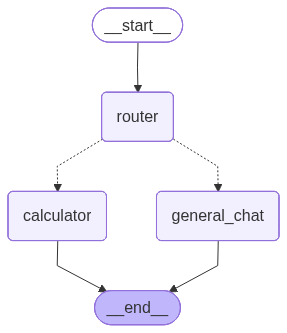

In [6]:
app

## 6. 실험: Routing 테스트
일반 질문과 수학 질문을 던졌을 때 경로가 어떻게 달라지는지 확인합니다.

In [7]:
test_questions = [
    "요즘 날씨가 너무 덥지 않아? 바다 놀러가고 싶다.",
    "245에 18을 곱하고 거기서 10%를 빼면 얼마일까?"
]

for q in test_questions:
    print(f"\n\n🗣️ 사용자: {q}")
    # stream()을 쓰면 노드 간 이동 과정을 눈으로 볼 수 있습니다.
    for output in app.stream({"question": q}):
        # output은 {현재_실행된_노드명: 상태데이터} 형태입니다.
        for node_name, state_data in output.items():
            if node_name != "router": # 라우터 노드 다음의 결과만 출력
                print(f"\n🤖 봇 답변: {state_data['answer']}")



🗣️ 사용자: 요즘 날씨가 너무 덥지 않아? 바다 놀러가고 싶다.
--- [Node: Router] 질문 분석 중 ---
--- [Node: General Chat] 일반 대화 모드 작동 ---

🤖 봇 답변: 정말 덥죠! 그런 날씨에는 시원한 바다 생각이 절로 날 것 같아요. 바다에 가서 상큼한 바람도 맞고, 파도 소리도 듣고, 여유로운 시간을 보내면 좋겠네요. 혹시 가고 싶은 바다나 해변이 있어요? 함께 이야기해보고 싶어!


🗣️ 사용자: 245에 18을 곱하고 거기서 10%를 빼면 얼마일까?
--- [Node: Router] 질문 분석 중 ---
--- [Node: Calculator] 수학 계산 모드 작동 ---

🤖 봇 답변: 245에 18을 곱한 후, 그 결과에서 10%를 빼는 단계를 차례대로 계산해보겠습니다.

1. **곱하기**: 먼저 245와 18을 곱합니다.
   \[
   245 \times 18
   \]

   계산을 통해,
   \[
   245 \times 18 = 4410
   \]

2. **10% 계산하기**: 이제 4410의 10%를 계산합니다. 10%는 0.10을 곱하는 것으로 구할 수 있습니다.
   \[
   4410 \times 0.10 = 441
   \]

3. **결과에서 10% 빼기**: 마지막으로 원래의 곱한 값에서 10%인 441을 빼줍니다.
   \[
   4410 - 441
   \]

   계산을 통해,
   \[
   4410 - 441 = 3969
   \]

결국, 245에 18을 곱하고 거기서 10%를 빼면 **3969**가 됩니다.


## 7. 결과 해석

1. **라우팅의 위력**: LangChain 기본 모듈로는 이렇게 명확한 분기 처리를 하기가 매우 까다롭습니다. 하지만 LangGraph를 쓰면 "고객 클레임 부서", "환불 부서", "일반 안내 부서" 등 봇의 페르소나와 처리 로직을 완전히 물리적으로 분리할 수 있습니다.
2. **유지보수성**: 계산 로직에 문제가 생기면 `node_calculator` 함수만 수정하면 됩니다. 전체 파이프라인의 안정성이 극대화됩니다.